# COMP6252 CW1 – Music Genre Classification
### GTZAN Dataset | Net1 to Net4

## 1. Imports & Setup

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Data Loading & Splitting (Shared for Net1–Net4)

In [2]:
# Path to GTZAN images_original folder
DATA_DIR = './Data/images_original'
IMG_SIZE = 180
BATCH_SIZE = 32
NUM_CLASSES = 10

# Transform: Resize to 180x180 and convert to tensor
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
print(f'Total samples: {len(full_dataset)}')
print(f'Classes: {full_dataset.classes}')

# Split: 70% train, 20% val, 10% test
total = len(full_dataset)
train_size = int(0.7 * total)
val_size   = int(0.2 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])
print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

# DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

Total samples: 999
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train: 699 | Val: 199 | Test: 101


## 3. Training & Evaluation Helpers

In [3]:
def train_model(model, optimizer, criterion, train_loader, val_loader, epochs=50, model_name='Model'):
    """Train a model and return history."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100. * correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc   = 100. * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'[{model_name}] Epoch {epoch+1}/{epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    return history


def evaluate_model(model, test_loader, model_name='Model'):
    """Evaluate model on test set."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100. * correct / total
    print(f'[{model_name}] Test Accuracy: {acc:.2f}%')
    return acc


def plot_history(history, model_name='Model', epochs=50):
    """Plot training/validation loss and accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'],   label='Val Loss')
    ax1.set_title(f'{model_name} – Loss ({epochs} epochs)')
    ax1.set_xlabel('Epoch'); ax1.legend()

    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'],   label='Val Acc')
    ax2.set_title(f'{model_name} – Accuracy ({epochs} epochs)')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('%'); ax2.legend()
    plt.tight_layout(); plt.show()

## 4. Net1 – Fully Connected Network (2 Hidden Layers)

[Net1] Epoch 10/50 | Train Loss: 1.7664 Acc: 41.20% | Val Loss: 1.7240 Acc: 38.69%
[Net1] Epoch 20/50 | Train Loss: 1.5084 Acc: 47.93% | Val Loss: 1.6211 Acc: 42.71%
[Net1] Epoch 30/50 | Train Loss: 1.3342 Acc: 51.79% | Val Loss: 1.5865 Acc: 45.23%
[Net1] Epoch 40/50 | Train Loss: 1.2209 Acc: 59.23% | Val Loss: 1.5257 Acc: 46.73%
[Net1] Epoch 50/50 | Train Loss: 1.0495 Acc: 62.52% | Val Loss: 1.4702 Acc: 51.76%
[Net1 (50 epochs)] Test Accuracy: 48.51%


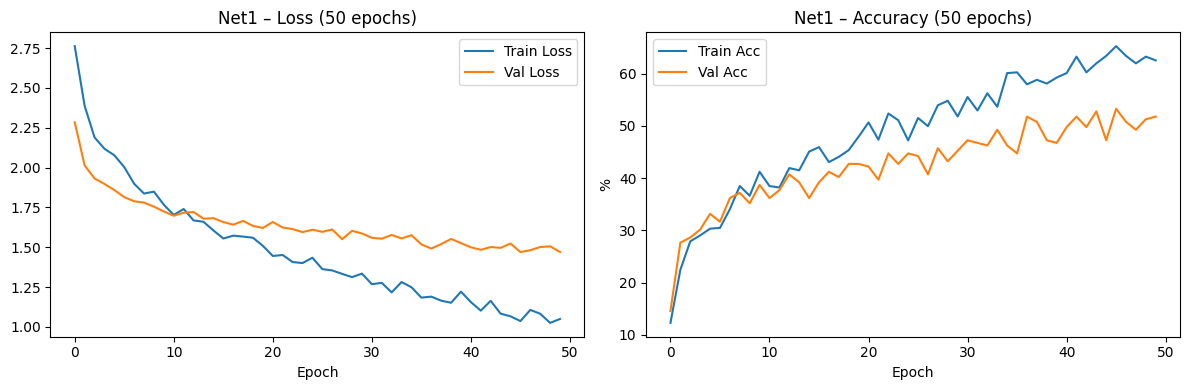

[Net1] Epoch 10/100 | Train Loss: 1.7943 Acc: 41.06% | Val Loss: 1.7200 Acc: 38.69%
[Net1] Epoch 20/100 | Train Loss: 1.5213 Acc: 47.93% | Val Loss: 1.6280 Acc: 40.70%
[Net1] Epoch 30/100 | Train Loss: 1.3360 Acc: 53.22% | Val Loss: 1.5580 Acc: 45.73%
[Net1] Epoch 40/100 | Train Loss: 1.1582 Acc: 57.08% | Val Loss: 1.5482 Acc: 46.23%
[Net1] Epoch 50/100 | Train Loss: 1.0528 Acc: 64.66% | Val Loss: 1.5683 Acc: 47.74%
[Net1] Epoch 60/100 | Train Loss: 0.9305 Acc: 67.10% | Val Loss: 1.5112 Acc: 50.25%
[Net1] Epoch 70/100 | Train Loss: 0.8909 Acc: 69.67% | Val Loss: 1.4948 Acc: 53.77%
[Net1] Epoch 80/100 | Train Loss: 0.7612 Acc: 72.39% | Val Loss: 1.4836 Acc: 54.27%
[Net1] Epoch 90/100 | Train Loss: 0.6831 Acc: 76.68% | Val Loss: 1.5143 Acc: 52.26%
[Net1] Epoch 100/100 | Train Loss: 0.6365 Acc: 80.83% | Val Loss: 1.4495 Acc: 53.77%
[Net1 (100 epochs)] Test Accuracy: 55.45%


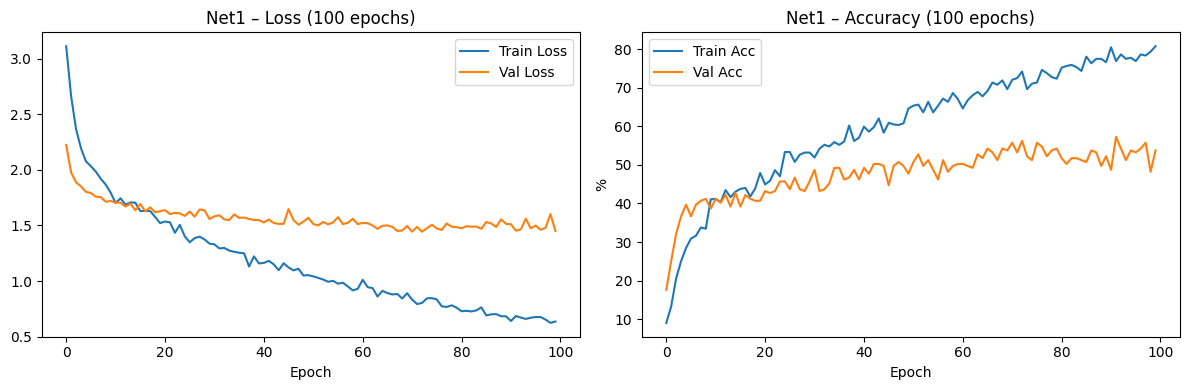

In [4]:
class Net1(nn.Module):
    """Fully connected network with 2 hidden layers.
    Uses AdaptiveAvgPool2d to reduce 180x180 -> 16x16 before flattening,
    making FC layers tractable and avoiding gradient vanishing issues.
    """
    def __init__(self, hidden1=512, hidden2=256, num_classes=NUM_CLASSES):
        super(Net1, self).__init__()
        self.pool = nn.AdaptiveAvgPool2d((16, 16))  # Reduce spatial dims
        input_size = 3 * 16 * 16  # 768 instead of 97200
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden2, num_classes)
        )
        # He initialisation for better gradient flow
        for m in self.fc:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def forward(self, x):
        x = self.pool(x)
        return self.fc(x)

criterion = nn.CrossEntropyLoss()

# --- 50 Epochs ---
net1 = Net1().to(device)
optimizer1 = optim.Adam(net1.parameters(), lr=1e-4, weight_decay=1e-4)
history_net1_50 = train_model(net1, optimizer1, criterion, train_loader, val_loader, epochs=50, model_name='Net1')
acc_net1_50 = evaluate_model(net1, test_loader, model_name='Net1 (50 epochs)')
plot_history(history_net1_50, model_name='Net1', epochs=50)

# --- 100 Epochs ---
net1_100 = Net1().to(device)
optimizer1_100 = optim.Adam(net1_100.parameters(), lr=1e-4, weight_decay=1e-4)
history_net1_100 = train_model(net1_100, optimizer1_100, criterion, train_loader, val_loader, epochs=100, model_name='Net1')
acc_net1_100 = evaluate_model(net1_100, test_loader, model_name='Net1 (100 epochs)')
plot_history(history_net1_100, model_name='Net1', epochs=100)

## 5. Net2 – CNN (Figure 1 Architecture)

[Net2] Epoch 10/50 | Train Loss: 2.0164 Acc: 25.32% | Val Loss: 2.0162 Acc: 21.61%
[Net2] Epoch 20/50 | Train Loss: 1.9058 Acc: 29.47% | Val Loss: 1.9363 Acc: 27.14%
[Net2] Epoch 30/50 | Train Loss: 1.7825 Acc: 33.76% | Val Loss: 1.8158 Acc: 31.16%
[Net2] Epoch 40/50 | Train Loss: 1.6495 Acc: 40.06% | Val Loss: 1.7700 Acc: 32.66%
[Net2] Epoch 50/50 | Train Loss: 1.4849 Acc: 48.21% | Val Loss: 1.6268 Acc: 36.18%
[Net2 (50 epochs)] Test Accuracy: 49.50%


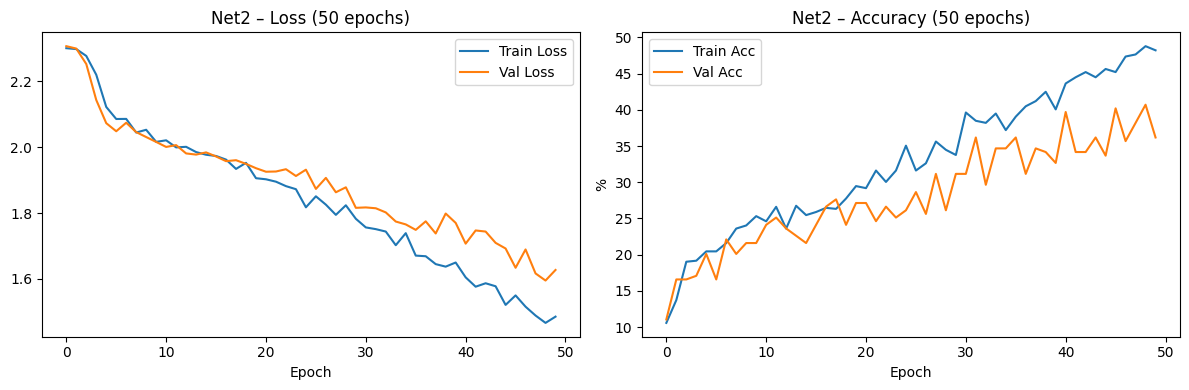

[Net2] Epoch 10/100 | Train Loss: 2.0480 Acc: 23.18% | Val Loss: 2.0214 Acc: 23.62%
[Net2] Epoch 20/100 | Train Loss: 1.9396 Acc: 27.90% | Val Loss: 1.9289 Acc: 23.62%
[Net2] Epoch 30/100 | Train Loss: 1.8208 Acc: 33.91% | Val Loss: 1.8561 Acc: 29.65%
[Net2] Epoch 40/100 | Train Loss: 1.6253 Acc: 42.20% | Val Loss: 1.7360 Acc: 34.17%
[Net2] Epoch 50/100 | Train Loss: 1.5675 Acc: 44.92% | Val Loss: 1.6680 Acc: 37.69%
[Net2] Epoch 60/100 | Train Loss: 1.4012 Acc: 49.36% | Val Loss: 1.5817 Acc: 40.70%
[Net2] Epoch 70/100 | Train Loss: 1.3561 Acc: 49.64% | Val Loss: 1.5315 Acc: 40.70%
[Net2] Epoch 80/100 | Train Loss: 1.2564 Acc: 53.79% | Val Loss: 1.4698 Acc: 49.25%
[Net2] Epoch 90/100 | Train Loss: 1.2347 Acc: 55.08% | Val Loss: 1.4372 Acc: 52.26%
[Net2] Epoch 100/100 | Train Loss: 1.1766 Acc: 58.66% | Val Loss: 1.4318 Acc: 50.25%
[Net2 (100 epochs)] Test Accuracy: 60.40%


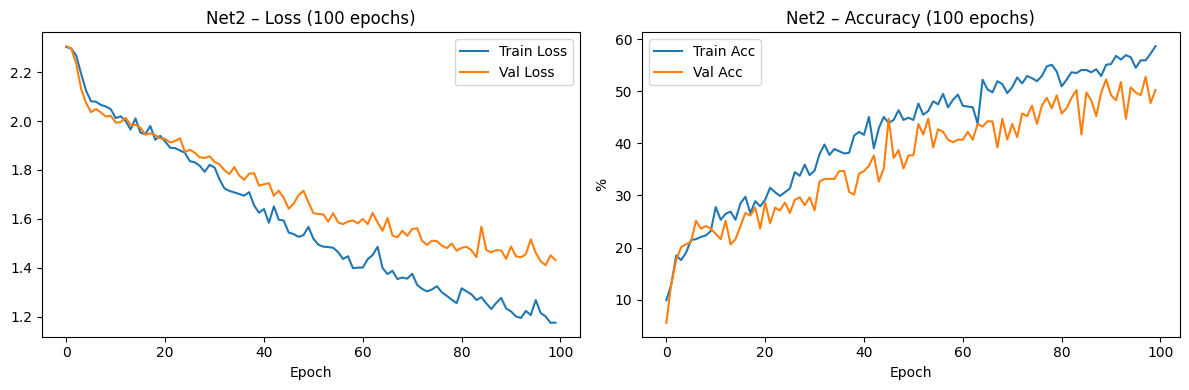

In [5]:
class Net2(nn.Module):
    """CNN from Figure 1: conv1->conv2->MaxPool->conv3->conv4->MaxPool->AdaptivePool->FC(256)->FC(10)"""
    def __init__(self, num_classes=NUM_CLASSES):
        super(Net2, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),    # conv1
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # conv2
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                             # MaxPool1
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # conv3
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # conv4
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                             # MaxPool2
        )
        # AdaptiveAvgPool reduces any spatial size to 4x4 -> 256*4*4=4096
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),  # out_features = 256 as per Figure 1
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        return self.classifier(x)

# --- 50 Epochs ---
net2 = Net2().to(device)
optimizer2 = optim.Adam(net2.parameters(), lr=1e-4, weight_decay=1e-4)
history_net2_50 = train_model(net2, optimizer2, criterion, train_loader, val_loader, epochs=50, model_name='Net2')
acc_net2_50 = evaluate_model(net2, test_loader, model_name='Net2 (50 epochs)')
plot_history(history_net2_50, model_name='Net2', epochs=50)

# --- 100 Epochs ---
net2_100 = Net2().to(device)
optimizer2_100 = optim.Adam(net2_100.parameters(), lr=1e-4, weight_decay=1e-4)
history_net2_100 = train_model(net2_100, optimizer2_100, criterion, train_loader, val_loader, epochs=100, model_name='Net2')
acc_net2_100 = evaluate_model(net2_100, test_loader, model_name='Net2 (100 epochs)')
plot_history(history_net2_100, model_name='Net2', epochs=100)

## 6. Net3 – CNN + Batch Normalisation

[Net3] Epoch 10/50 | Train Loss: 1.4768 Acc: 48.93% | Val Loss: 1.4631 Acc: 46.23%
[Net3] Epoch 20/50 | Train Loss: 1.2367 Acc: 58.37% | Val Loss: 1.6318 Acc: 39.20%
[Net3] Epoch 30/50 | Train Loss: 1.0660 Acc: 62.80% | Val Loss: 1.2788 Acc: 56.78%
[Net3] Epoch 40/50 | Train Loss: 0.9432 Acc: 68.96% | Val Loss: 1.1614 Acc: 64.32%
[Net3] Epoch 50/50 | Train Loss: 0.8452 Acc: 71.96% | Val Loss: 1.1653 Acc: 63.82%
[Net3 (50 epochs)] Test Accuracy: 70.30%


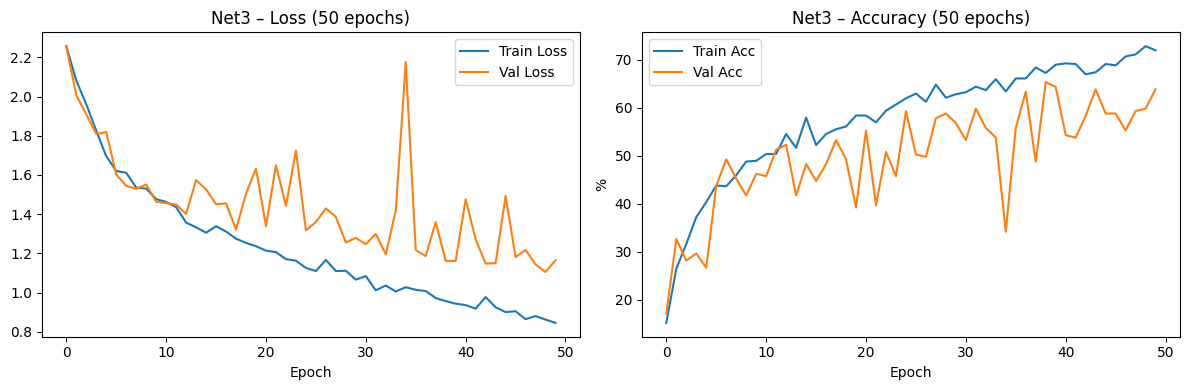

[Net3] Epoch 10/100 | Train Loss: 1.4934 Acc: 47.64% | Val Loss: 1.4295 Acc: 53.77%
[Net3] Epoch 20/100 | Train Loss: 1.2173 Acc: 59.23% | Val Loss: 1.3030 Acc: 55.28%
[Net3] Epoch 30/100 | Train Loss: 1.0653 Acc: 64.38% | Val Loss: 1.4215 Acc: 52.26%
[Net3] Epoch 40/100 | Train Loss: 0.9394 Acc: 68.53% | Val Loss: 1.1608 Acc: 63.32%
[Net3] Epoch 50/100 | Train Loss: 0.8347 Acc: 71.39% | Val Loss: 1.0406 Acc: 63.82%
[Net3] Epoch 60/100 | Train Loss: 0.7631 Acc: 73.53% | Val Loss: 1.0413 Acc: 64.32%
[Net3] Epoch 70/100 | Train Loss: 0.6354 Acc: 79.97% | Val Loss: 0.9635 Acc: 68.34%
[Net3] Epoch 80/100 | Train Loss: 0.6289 Acc: 79.26% | Val Loss: 1.1128 Acc: 67.84%
[Net3] Epoch 90/100 | Train Loss: 0.5336 Acc: 83.83% | Val Loss: 1.0008 Acc: 69.85%
[Net3] Epoch 100/100 | Train Loss: 0.4526 Acc: 84.69% | Val Loss: 1.0210 Acc: 71.36%
[Net3 (100 epochs)] Test Accuracy: 70.30%


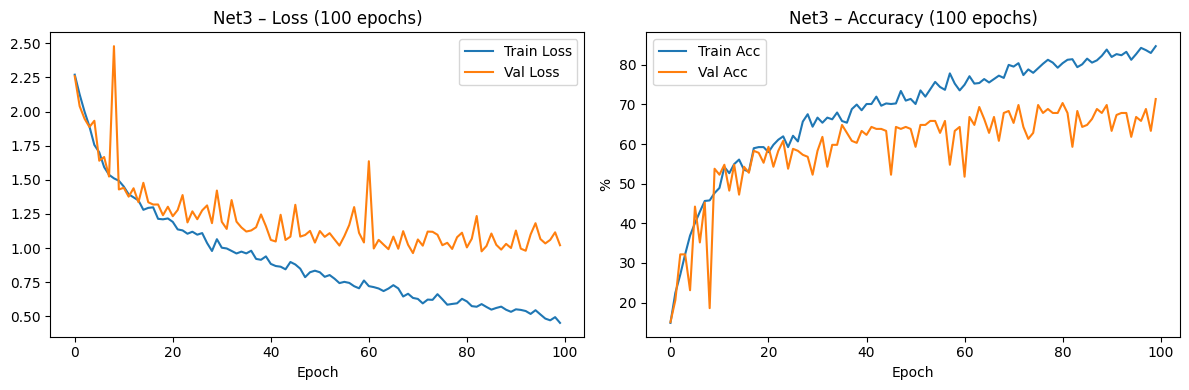

In [6]:
class Net3(nn.Module):
    """Net2 + Batch Normalisation after each conv layer."""
    def __init__(self, num_classes=NUM_CLASSES):
        super(Net3, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        return self.classifier(x)

# --- 50 Epochs ---
net3 = Net3().to(device)
optimizer3 = optim.Adam(net3.parameters(), lr=1e-4, weight_decay=1e-4)
history_net3_50 = train_model(net3, optimizer3, criterion, train_loader, val_loader, epochs=50, model_name='Net3')
acc_net3_50 = evaluate_model(net3, test_loader, model_name='Net3 (50 epochs)')
plot_history(history_net3_50, model_name='Net3', epochs=50)

# --- 100 Epochs ---
net3_100 = Net3().to(device)
optimizer3_100 = optim.Adam(net3_100.parameters(), lr=1e-4, weight_decay=1e-4)
history_net3_100 = train_model(net3_100, optimizer3_100, criterion, train_loader, val_loader, epochs=100, model_name='Net3')
acc_net3_100 = evaluate_model(net3_100, test_loader, model_name='Net3 (100 epochs)')
plot_history(history_net3_100, model_name='Net3', epochs=100)

## 7. Net4 – CNN + Batch Normalisation + RMSProp

[Net4] Epoch 10/50 | Train Loss: 1.4623 Acc: 48.35% | Val Loss: 1.4853 Acc: 51.76%
[Net4] Epoch 20/50 | Train Loss: 1.2467 Acc: 58.51% | Val Loss: 1.6560 Acc: 44.22%
[Net4] Epoch 30/50 | Train Loss: 1.0613 Acc: 64.23% | Val Loss: 1.1860 Acc: 59.30%
[Net4] Epoch 40/50 | Train Loss: 0.9821 Acc: 65.09% | Val Loss: 1.2706 Acc: 59.80%
[Net4] Epoch 50/50 | Train Loss: 0.8660 Acc: 70.82% | Val Loss: 1.0921 Acc: 61.81%
[Net4 (50 epochs)] Test Accuracy: 65.35%


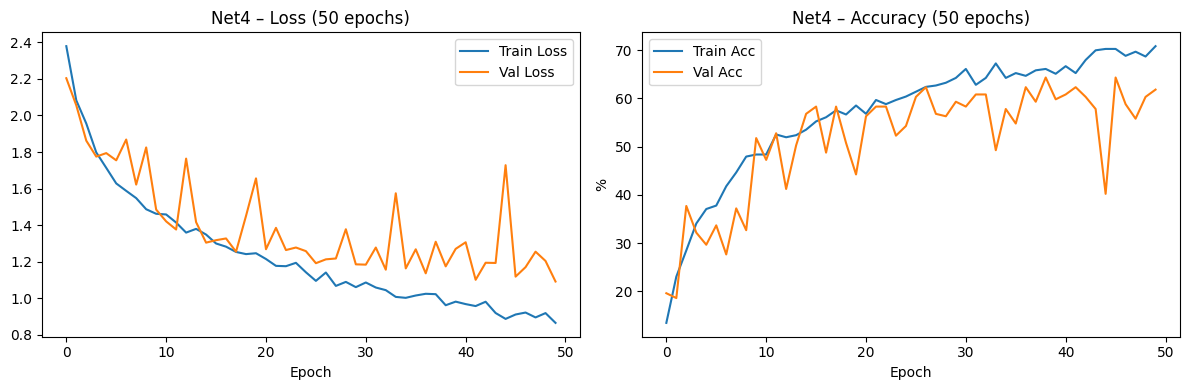

[Net4] Epoch 10/100 | Train Loss: 1.4629 Acc: 48.93% | Val Loss: 1.4265 Acc: 54.27%
[Net4] Epoch 20/100 | Train Loss: 1.1816 Acc: 59.37% | Val Loss: 1.2578 Acc: 56.78%
[Net4] Epoch 30/100 | Train Loss: 1.0385 Acc: 63.52% | Val Loss: 1.2119 Acc: 57.79%
[Net4] Epoch 40/100 | Train Loss: 0.9631 Acc: 64.95% | Val Loss: 1.2138 Acc: 60.80%
[Net4] Epoch 50/100 | Train Loss: 0.8415 Acc: 71.67% | Val Loss: 1.0880 Acc: 61.81%
[Net4] Epoch 60/100 | Train Loss: 0.7749 Acc: 73.39% | Val Loss: 1.1486 Acc: 64.32%
[Net4] Epoch 70/100 | Train Loss: 0.6954 Acc: 77.68% | Val Loss: 1.0382 Acc: 64.82%
[Net4] Epoch 80/100 | Train Loss: 0.7085 Acc: 76.68% | Val Loss: 1.1401 Acc: 64.32%
[Net4] Epoch 90/100 | Train Loss: 0.6494 Acc: 78.11% | Val Loss: 1.3485 Acc: 61.81%
[Net4] Epoch 100/100 | Train Loss: 0.5302 Acc: 82.12% | Val Loss: 1.0631 Acc: 68.84%
[Net4 (100 epochs)] Test Accuracy: 70.30%


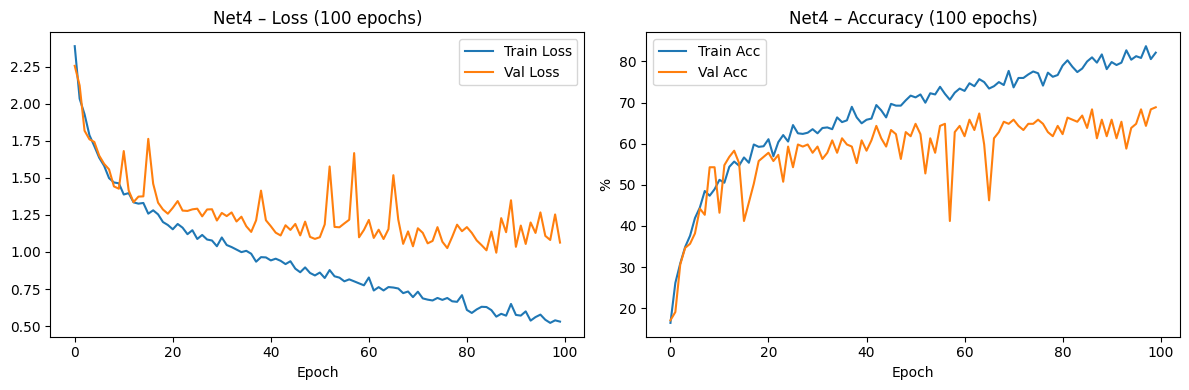

In [7]:
class Net4(nn.Module):
    """Same as Net3, but trained with RMSProp optimiser."""
    def __init__(self, num_classes=NUM_CLASSES):
        super(Net4, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        return self.classifier(x)

# --- 50 Epochs (RMSProp) ---
net4 = Net4().to(device)
optimizer4 = optim.RMSprop(net4.parameters(), lr=1e-4, weight_decay=1e-4)
history_net4_50 = train_model(net4, optimizer4, criterion, train_loader, val_loader, epochs=50, model_name='Net4')
acc_net4_50 = evaluate_model(net4, test_loader, model_name='Net4 (50 epochs)')
plot_history(history_net4_50, model_name='Net4', epochs=50)

# --- 100 Epochs (RMSProp) ---
net4_100 = Net4().to(device)
optimizer4_100 = optim.RMSprop(net4_100.parameters(), lr=1e-4, weight_decay=1e-4)
history_net4_100 = train_model(net4_100, optimizer4_100, criterion, train_loader, val_loader, epochs=100, model_name='Net4')
acc_net4_100 = evaluate_model(net4_100, test_loader, model_name='Net4 (100 epochs)')
plot_history(history_net4_100, model_name='Net4', epochs=100)

## 8. Net5 – LSTM on Raw Audio

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np


class GTZANSequenceDataset(Dataset):
    """Groups 3-sec CSV features into sequences of 10 per song for LSTM."""
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)
        df = df.drop(columns=['filename', 'length'], errors='ignore')

        le = LabelEncoder()
        labels = le.fit_transform(df['label'])
        df = df.drop(columns=['label'])

        scaler = StandardScaler()
        features = scaler.fit_transform(df.values).astype(np.float32)

        # Group into sequences of 10 (one per full song)
        self.sequences = []
        self.labels    = []
        n_chunks = 10
        for i in range(0, len(features) - n_chunks + 1, n_chunks):
            seq   = features[i:i + n_chunks]       # (10, 57)
            label = labels[i + n_chunks // 2]       # label of middle chunk
            self.sequences.append(seq)
            self.labels.append(label)

        self.classes = list(le.classes_)
        print(f'Loaded {len(self.sequences)} sequences of shape (10, {features.shape[1]})')
        print(f'Classes: {self.classes}')

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (torch.tensor(self.sequences[idx]),
                torch.tensor(self.labels[idx], dtype=torch.long))


CSV_PATH = './Data/features_3_sec.csv'
audio_dataset = GTZANSequenceDataset(CSV_PATH)

total_a = len(audio_dataset)
train_a = int(0.7 * total_a)
val_a   = int(0.2 * total_a)
test_a  = total_a - train_a - val_a
train_audio, val_audio, test_audio = random_split(
    audio_dataset, [train_a, val_a, test_a],
    generator=torch.Generator().manual_seed(42)
)
print(f'Split — Train: {train_a} | Val: {val_a} | Test: {test_a}')

train_audio_loader = DataLoader(train_audio, batch_size=32, shuffle=True)
val_audio_loader   = DataLoader(val_audio,   batch_size=32, shuffle=False)
test_audio_loader  = DataLoader(test_audio,  batch_size=32, shuffle=False)

Loaded 999 sequences of shape (10, 57)
Classes: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Split — Train: 699 | Val: 199 | Test: 101


Training Net5 (LSTM)...
[Net5] Epoch 10/100 | Train Loss: 0.1986 Acc: 93.71% | Val Loss: 0.8301 Acc: 80.40%
[Net5] Epoch 20/100 | Train Loss: 0.0055 Acc: 100.00% | Val Loss: 1.1140 Acc: 81.91%
Early stopping at epoch 25
[Net5 (LSTM)] Test Accuracy: 78.22%


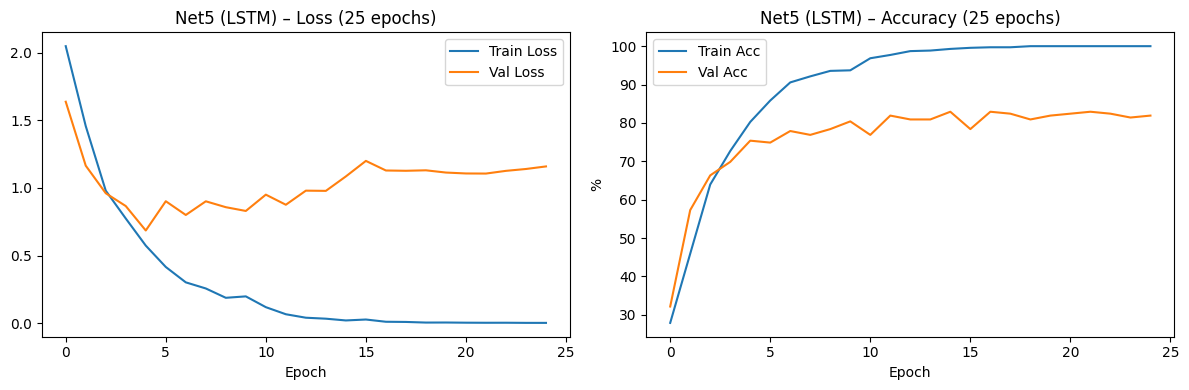

In [9]:
# ----------------------------------------------------------------
# Net5: LSTM classifier on 3-sec CSV feature sequences
# ----------------------------------------------------------------
class Net5(nn.Module):
    """Bidirectional LSTM on sequences of 3-sec audio features."""
    def __init__(self, input_size=57, hidden_size=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super(Net5, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (batch, 10, 57)
        out, (hn, _) = self.lstm(x)
        hn_fwd = hn[-2]
        hn_bwd = hn[-1]
        return self.classifier(torch.cat([hn_fwd, hn_bwd], dim=1))


net5 = Net5().to(device)
optimizer5 = optim.Adam(net5.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler5 = optim.lr_scheduler.ReduceLROnPlateau(optimizer5, patience=5, factor=0.5)

best_val_loss = float('inf')
patience, patience_counter = 20, 0
history_net5 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
MAX_EPOCHS = 100

print('Training Net5 (LSTM)...')
for epoch in range(MAX_EPOCHS):
    net5.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in train_audio_loader:
        x, y = x.to(device), y.to(device)
        optimizer5.zero_grad()
        out  = net5(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(net5.parameters(), max_norm=1.0)
        optimizer5.step()
        running_loss += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total   += y.size(0)

    train_loss = running_loss / total
    train_acc  = 100. * correct / total

    net5.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_audio_loader:
            x, y = x.to(device), y.to(device)
            out          = net5(x)
            val_loss    += criterion(out, y).item() * x.size(0)
            val_correct += out.argmax(1).eq(y).sum().item()
            val_total   += y.size(0)

    val_loss /= val_total
    val_acc   = 100. * val_correct / val_total

    history_net5['train_loss'].append(train_loss)
    history_net5['val_loss'].append(val_loss)
    history_net5['train_acc'].append(train_acc)
    history_net5['val_acc'].append(val_acc)

    scheduler5.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'[Net5] Epoch {epoch+1}/{MAX_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(net5.state_dict(), 'best_net5.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

net5.load_state_dict(torch.load('best_net5.pth'))
acc_net5 = evaluate_model(net5, test_audio_loader, model_name='Net5 (LSTM)')
plot_history(history_net5, model_name='Net5 (LSTM)', epochs=len(history_net5['train_loss']))

## 9. Net6 – LSTM + GAN Audio Augmentation

In [10]:
# ----------------------------------------------------------------
# GAN: Generator and Discriminator on CSV feature space (10, 57)
# ----------------------------------------------------------------
LATENT_DIM  = 100
GAN_EPOCHS  = 100
GAN_SEQ_LEN = 10   # matches GTZANSequenceDataset sequence length
GAN_N_FEAT  = 57   # matches number of CSV features

class GANGenerator(nn.Module):
    """Generates fake feature sequences from Gaussian noise + class label."""
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES,
                 seq_len=GAN_SEQ_LEN, n_feat=GAN_N_FEAT):
        super(GANGenerator, self).__init__()
        self.seq_len = seq_len
        self.n_feat  = n_feat
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, seq_len * n_feat),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)
        out = self.net(x)
        return out.view(-1, self.seq_len, self.n_feat)


class GANDiscriminator(nn.Module):
    """Classifies feature sequences as real or fake."""
    def __init__(self, num_classes=NUM_CLASSES, seq_len=GAN_SEQ_LEN, n_feat=GAN_N_FEAT):
        super(GANDiscriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.net = nn.Sequential(
            nn.Linear(seq_len * n_feat + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        x_flat      = x.view(x.size(0), -1)
        label_input = self.label_emb(labels)
        inp = torch.cat([x_flat, label_input], dim=1)
        return self.net(inp)


# --- Train GAN ---
generator     = GANGenerator().to(device)
discriminator = GANDiscriminator().to(device)
opt_G = optim.Adam(generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

print('Training GAN for audio augmentation...')
for epoch in range(GAN_EPOCHS):
    for real_x, real_y in train_audio_loader:
        real_x, real_y = real_x.to(device), real_y.to(device)
        batch_size = real_x.size(0)
        real_labels_gan = torch.ones(batch_size, 1).to(device)
        fake_labels_gan = torch.zeros(batch_size, 1).to(device)

        # --- Train Discriminator ---
        noise  = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_x = generator(noise, real_y).detach()
        loss_D = bce(discriminator(real_x, real_y), real_labels_gan) + \
                 bce(discriminator(fake_x,  real_y), fake_labels_gan)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train Generator ---
        noise  = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_x = generator(noise, real_y)
        loss_G = bce(discriminator(fake_x, real_y), real_labels_gan)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    if (epoch + 1) % 20 == 0:
        print(f'[GAN] Epoch {epoch+1}/{GAN_EPOCHS} | Loss_D: {loss_D.item():.4f} | Loss_G: {loss_G.item():.4f}')

print('GAN training complete.')

Training GAN for audio augmentation...
[GAN] Epoch 20/100 | Loss_D: 0.4858 | Loss_G: 2.7700
[GAN] Epoch 40/100 | Loss_D: 0.7253 | Loss_G: 2.7304
[GAN] Epoch 60/100 | Loss_D: 0.4970 | Loss_G: 3.0903
[GAN] Epoch 80/100 | Loss_D: 0.4228 | Loss_G: 3.4051
[GAN] Epoch 100/100 | Loss_D: 0.5367 | Loss_G: 4.3336
GAN training complete.


Augmented training set size: 1389 (real: 699 + fake: 690)
Training Net6 (LSTM + GAN augmentation)...
[Net6] Epoch 10/100 | Train Loss: 0.1411 Acc: 95.82% | Val Loss: 1.2935 Acc: 70.35%
[Net6] Epoch 20/100 | Train Loss: 0.0503 Acc: 98.70% | Val Loss: 1.6660 Acc: 71.36%
Early stopping at epoch 20
[Net6 (LSTM + GAN)] Test Accuracy: 74.26%


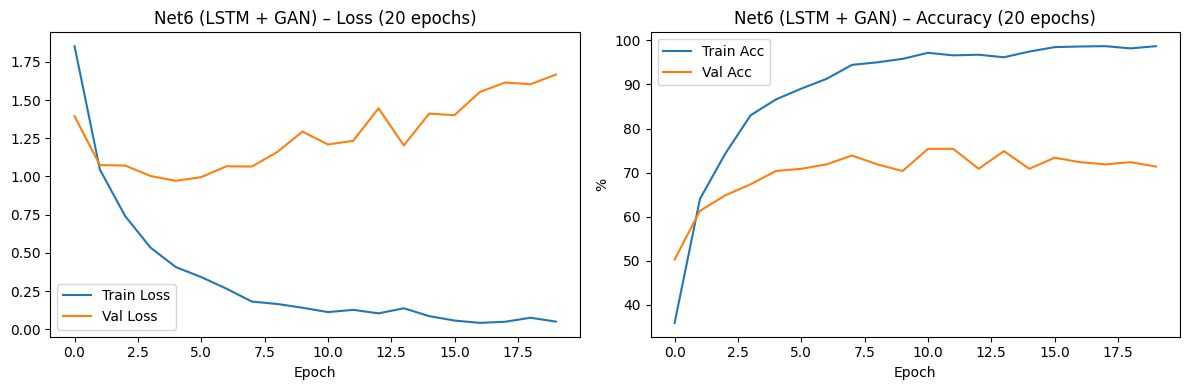

In [11]:
# ----------------------------------------------------------------
# Build augmented training set: real + GAN-generated samples
# ----------------------------------------------------------------
generator.eval()
aug_samples, aug_labels = [], []

# Generate same number of samples as training set (one per class proportionally)
samples_per_class = max(1, train_a // NUM_CLASSES)
with torch.no_grad():
    for class_idx in range(NUM_CLASSES):
        noise  = torch.randn(samples_per_class, LATENT_DIM).to(device)
        labels = torch.full((samples_per_class,), class_idx, dtype=torch.long).to(device)
        fake   = generator(noise, labels).cpu()
        aug_samples.append(fake)
        aug_labels.extend([class_idx] * samples_per_class)

aug_x = torch.cat(aug_samples, dim=0)  # (N_aug, 10, 57)
aug_y = torch.tensor(aug_labels, dtype=torch.long)

class AugmentedDataset(Dataset):
    def __init__(self, real_dataset, aug_x, aug_y):
        self.real  = real_dataset
        self.aug_x = aug_x
        self.aug_y = aug_y

    def __len__(self):
        return len(self.real) + len(self.aug_x)

    def __getitem__(self, idx):
        if idx < len(self.real):
            return self.real[idx]
        else:
            i = idx - len(self.real)
            return self.aug_x[i], self.aug_y[i]

augmented_train  = AugmentedDataset(train_audio, aug_x, aug_y)
aug_train_loader = DataLoader(augmented_train, batch_size=32, shuffle=True)
print(f'Augmented training set size: {len(augmented_train)} (real: {train_a} + fake: {len(aug_x)})')

# ----------------------------------------------------------------
# Net6: Same LSTM architecture, trained on augmented data
# ----------------------------------------------------------------
class Net6(nn.Module):
    """Same as Net5 LSTM, trained on GAN-augmented audio data."""
    def __init__(self, input_size=57, hidden_size=128, num_layers=2,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super(Net6, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        hn_fwd = hn[-2]
        hn_bwd = hn[-1]
        hn_cat = torch.cat([hn_fwd, hn_bwd], dim=1)
        return self.classifier(hn_cat)


net6 = Net6().to(device)
optimizer6 = optim.Adam(net6.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_loss6 = float('inf')
patience6, patience_counter6 = 15, 0
history_net6 = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Training Net6 (LSTM + GAN augmentation)...')
for epoch in range(MAX_EPOCHS):
    net6.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in aug_train_loader:
        x, y = x.to(device), y.to(device)
        optimizer6.zero_grad()
        out  = net6(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(net6.parameters(), max_norm=1.0)
        optimizer6.step()
        running_loss += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total   += y.size(0)

    train_loss = running_loss / total
    train_acc  = 100. * correct / total

    net6.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_audio_loader:
            x, y = x.to(device), y.to(device)
            out          = net6(x)
            val_loss    += criterion(out, y).item() * x.size(0)
            val_correct += out.argmax(1).eq(y).sum().item()
            val_total   += y.size(0)

    val_loss /= val_total
    val_acc   = 100. * val_correct / val_total

    history_net6['train_loss'].append(train_loss)
    history_net6['val_loss'].append(val_loss)
    history_net6['train_acc'].append(train_acc)
    history_net6['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f'[Net6] Epoch {epoch+1}/{MAX_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    if val_loss < best_val_loss6:
        best_val_loss6    = val_loss
        patience_counter6 = 0
        torch.save(net6.state_dict(), 'best_net6.pth')
    else:
        patience_counter6 += 1
        if patience_counter6 >= patience6:
            print(f'Early stopping at epoch {epoch+1}')
            break

net6.load_state_dict(torch.load('best_net6.pth'))
acc_net6 = evaluate_model(net6, test_audio_loader, model_name='Net6 (LSTM + GAN)')
plot_history(history_net6, model_name='Net6 (LSTM + GAN)', epochs=len(history_net6['train_loss']))

## 10. Results Summary

In [12]:
import pandas as pd

results = {
    'Model':        ['Net1', 'Net1', 'Net2', 'Net2', 'Net3', 'Net3', 'Net4', 'Net4', 'Net5', 'Net6'],
    'Architecture': ['FC', 'FC', 'CNN', 'CNN', 'CNN+BN', 'CNN+BN', 'CNN+BN', 'CNN+BN', 'LSTM', 'LSTM+GAN'],
    'Epochs':       [50, 100, 50, 100, 50, 100, 50, 100, 'Early Stop', 'Early Stop'],
    'Optimiser':    ['Adam']*6 + ['RMSProp']*2 + ['Adam']*2,
    'Test Acc (%)': [
        acc_net1_50, acc_net1_100,
        acc_net2_50, acc_net2_100,
        acc_net3_50, acc_net3_100,
        acc_net4_50, acc_net4_100,
        acc_net5,    acc_net6
    ]
}

df = pd.DataFrame(results)
print(df.to_string(index=False))

Model Architecture     Epochs Optimiser  Test Acc (%)
 Net1           FC         50      Adam     48.514851
 Net1           FC        100      Adam     55.445545
 Net2          CNN         50      Adam     49.504950
 Net2          CNN        100      Adam     60.396040
 Net3       CNN+BN         50      Adam     70.297030
 Net3       CNN+BN        100      Adam     70.297030
 Net4       CNN+BN         50   RMSProp     65.346535
 Net4       CNN+BN        100   RMSProp     70.297030
 Net5         LSTM Early Stop      Adam     78.217822
 Net6     LSTM+GAN Early Stop      Adam     74.257426


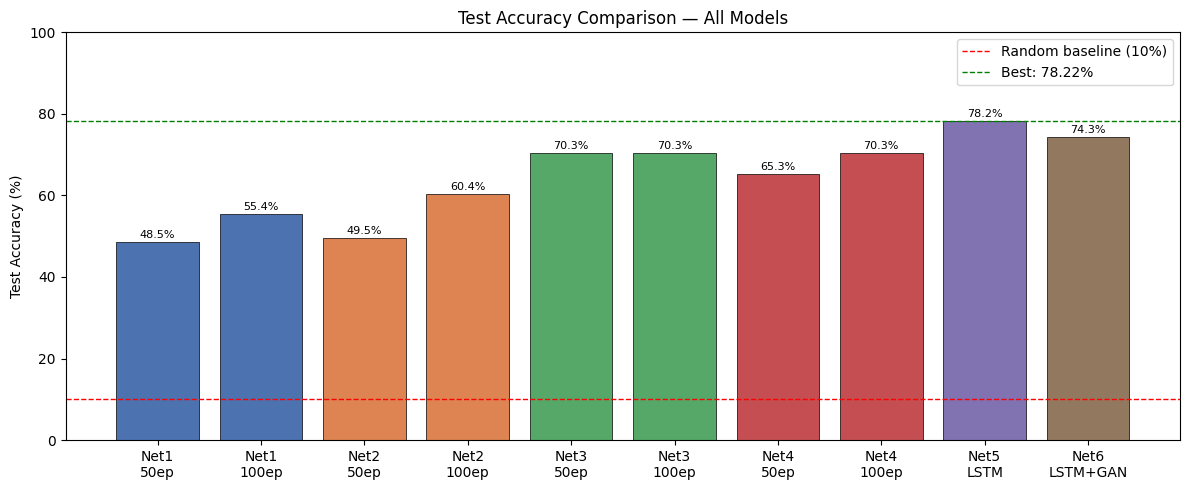

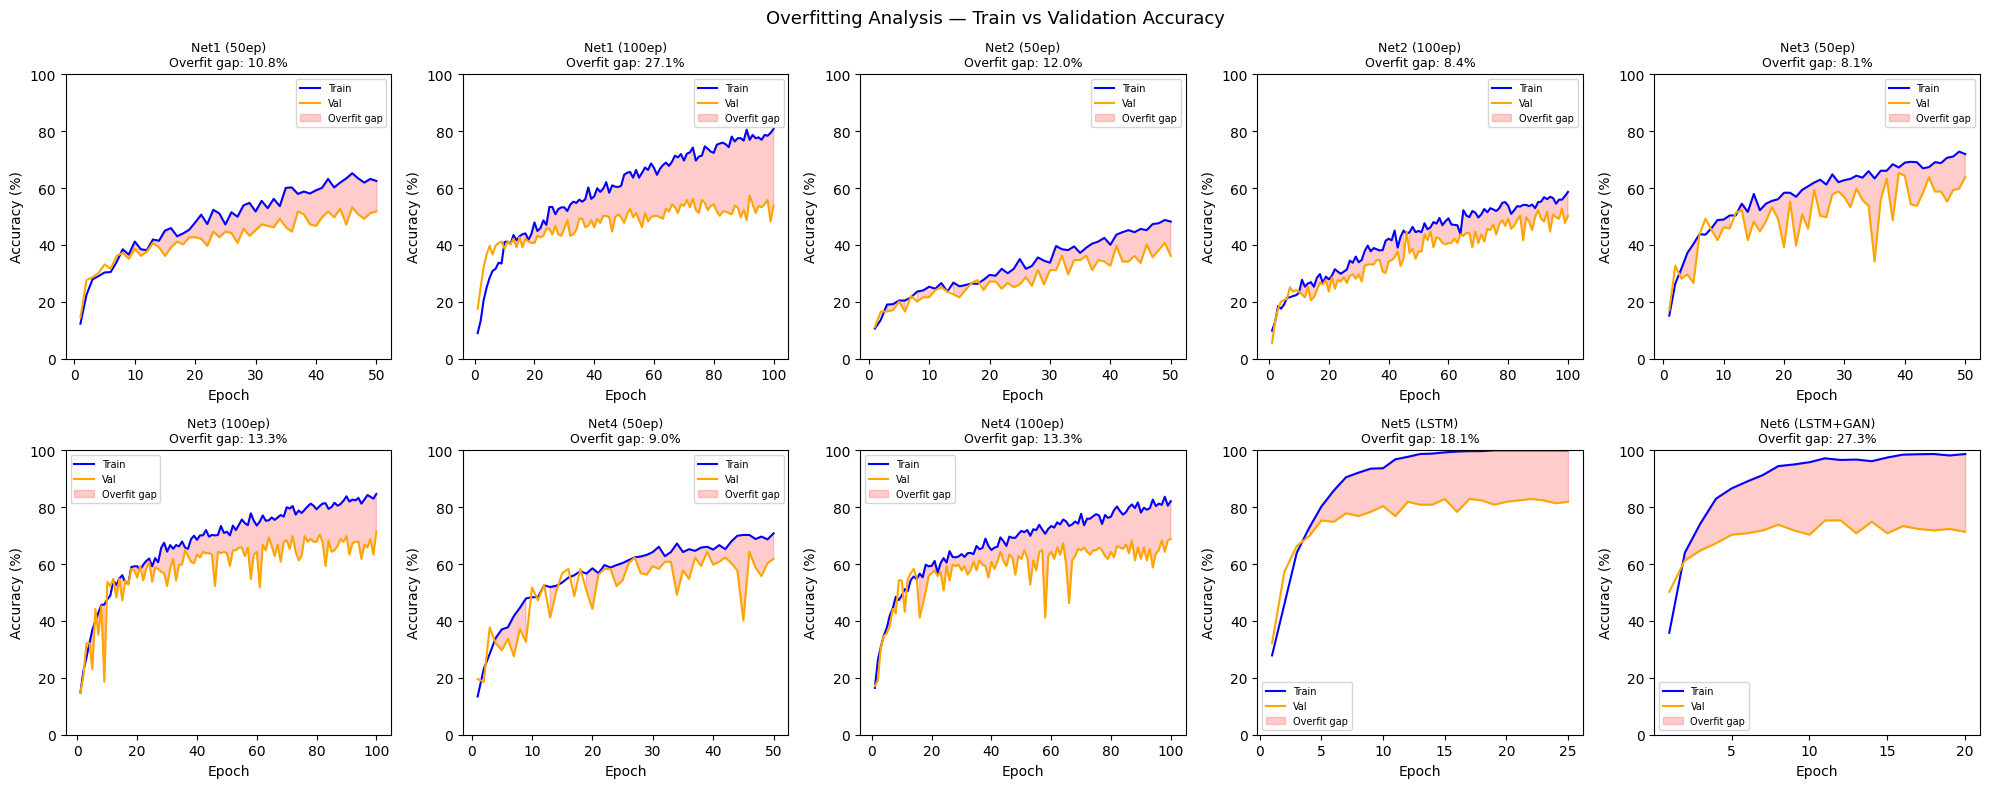

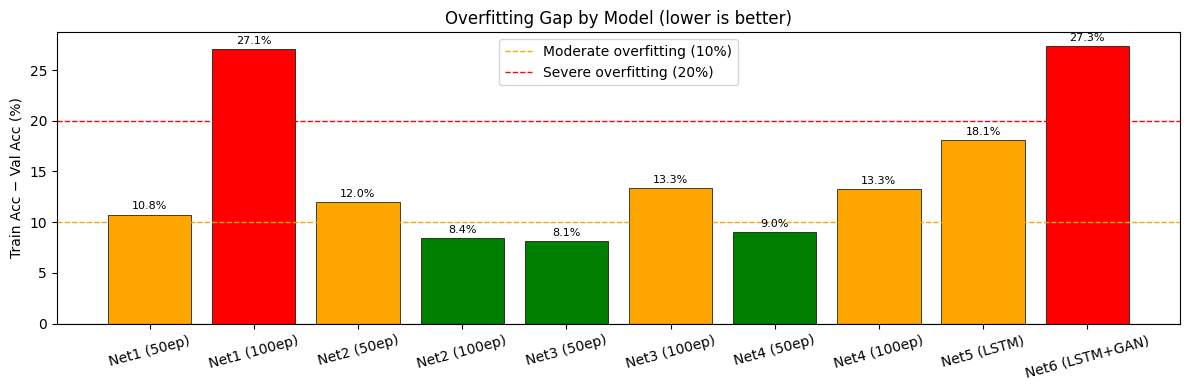


Model                  Test Acc  Train Acc    Val Acc      Gap
Net1 (50ep)               48.51      62.52      51.76    10.76 ✓
Net1 (100ep)              55.45      80.83      53.77    27.06OVERFIT
Net2 (50ep)               49.50      48.21      36.18    12.03 ✓
Net2 (100ep)              60.40      58.66      50.25     8.40 ✓
Net3 (50ep)               70.30      71.96      63.82     8.14 ✓
Net3 (100ep)              70.30      84.69      71.36    13.34 ✓
Net4 (50ep)               65.35      70.82      61.81     9.01 ✓
Net4 (100ep)              70.30      82.12      68.84    13.27 ✓
Net5 (LSTM)               78.22     100.00      81.91    18.09 ✓
Net6 (LSTM+GAN)           74.26      98.70      71.36    27.35OVERFIT

Best model: Net5
LSTM with 78.22% test accuracy


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------
# Collect all results
# ----------------------------------------------------------------
models = {
    'Net1 (FC)':       {'50': acc_net1_50,  '100': acc_net1_100, 'type': 'image'},
    'Net2 (CNN)':      {'50': acc_net2_50,  '100': acc_net2_100, 'type': 'image'},
    'Net3 (CNN+BN)':   {'50': acc_net3_50,  '100': acc_net3_100, 'type': 'image'},
    'Net4 (CNN+BN+R)': {'50': acc_net4_50,  '100': acc_net4_100, 'type': 'image'},
    'Net5 (LSTM)':     {'early_stop': acc_net5,                   'type': 'audio'},
    'Net6 (LSTM+GAN)': {'early_stop': acc_net6,                   'type': 'audio'},
}

# ----------------------------------------------------------------
# Plot 1: Test Accuracy Comparison Bar Chart
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

labels   = ['Net1\n50ep', 'Net1\n100ep', 'Net2\n50ep', 'Net2\n100ep',
             'Net3\n50ep', 'Net3\n100ep', 'Net4\n50ep', 'Net4\n100ep',
             'Net5\nLSTM', 'Net6\nLSTM+GAN']
accuracies = [acc_net1_50, acc_net1_100, acc_net2_50, acc_net2_100,
              acc_net3_50, acc_net3_100, acc_net4_50, acc_net4_100,
              acc_net5,    acc_net6]
colors = ['#4C72B0']*2 + ['#DD8452']*2 + ['#55A868']*2 + ['#C44E52']*2 + ['#8172B2', '#937860']

bars = ax.bar(labels, accuracies, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1, label='Random baseline (10%)')
ax.axhline(y=max(accuracies), color='green', linestyle='--', linewidth=1, label=f'Best: {max(accuracies):.2f}%')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison — All Models')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Plot 2: Overfitting Analysis — Train vs Val Accuracy
# ----------------------------------------------------------------
histories = {
    'Net1 (50ep)':  history_net1_50,
    'Net1 (100ep)': history_net1_100,
    'Net2 (50ep)':  history_net2_50,
    'Net2 (100ep)': history_net2_100,
    'Net3 (50ep)':  history_net3_50,
    'Net3 (100ep)': history_net3_100,
    'Net4 (50ep)':  history_net4_50,
    'Net4 (100ep)': history_net4_100,
    'Net5 (LSTM)':  history_net5,
    'Net6 (LSTM+GAN)': history_net6,
}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (name, history) in enumerate(histories.items()):
    ax = axes[idx]
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, history['train_acc'], label='Train', color='blue')
    ax.plot(epochs, history['val_acc'],   label='Val',   color='orange')

    # Shade overfitting region
    train_arr = np.array(history['train_acc'])
    val_arr   = np.array(history['val_acc'])
    ax.fill_between(epochs, val_arr, train_arr,
                    where=(train_arr > val_arr),
                    alpha=0.2, color='red', label='Overfit gap')

    final_gap = history['train_acc'][-1] - history['val_acc'][-1]
    ax.set_title(f'{name}\nOverfit gap: {final_gap:.1f}%', fontsize=9)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 100)

plt.suptitle('Overfitting Analysis — Train vs Validation Accuracy', fontsize=13)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Plot 3: Overfitting Gap Summary
# ----------------------------------------------------------------
gaps = {name: h['train_acc'][-1] - h['val_acc'][-1] for name, h in histories.items()}

fig, ax = plt.subplots(figsize=(12, 4))
colors  = ['red' if g > 20 else 'orange' if g > 10 else 'green' for g in gaps.values()]
bars    = ax.bar(gaps.keys(), gaps.values(), color=colors, edgecolor='black', linewidth=0.5)

for bar, gap in zip(bars, gaps.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{gap:.1f}%', ha='center', va='bottom', fontsize=8)

ax.axhline(y=0,  color='black', linewidth=0.8)
ax.axhline(y=10, color='orange', linestyle='--', linewidth=1, label='Moderate overfitting (10%)')
ax.axhline(y=20, color='red',    linestyle='--', linewidth=1, label='Severe overfitting (20%)')
ax.set_ylabel('Train Acc − Val Acc (%)')
ax.set_title('Overfitting Gap by Model (lower is better)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Summary Table
# ----------------------------------------------------------------
print('\n' + '='*65)
print(f'{"Model":<20} {"Test Acc":>10} {"Train Acc":>10} {"Val Acc":>10} {"Gap":>8}')
print('='*65)
for name, history in histories.items():
    test_acc  = accuracies[list(histories.keys()).index(name)]
    train_acc = history['train_acc'][-1]
    val_acc   = history['val_acc'][-1]
    gap       = train_acc - val_acc
    flag      = 'OVERFIT' if gap > 20 else ' ✓'
    print(f'{name:<20} {test_acc:>10.2f} {train_acc:>10.2f} {val_acc:>10.2f} {gap:>8.2f}{flag}')
print('='*65)
print(f'\nBest model: {labels[accuracies.index(max(accuracies))]} with {max(accuracies):.2f}% test accuracy')